In [1]:
%pip install pennylane pennylane-lightning matplotlib scipy --break-system-packages -q

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 57.3/57.3 kB 3.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.3/5.3 MB 38.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 935.6/935.6 kB 44.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 167.9/167.9 kB 8.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.5/2.5 MB 48.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.2/2.2 MB 59.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 8.9/8.9 MB 70.2 MB/s eta 0:00:00


In [6]:
import pennylane as qml
import numpy as np
from numpy.polynomial.chebyshev import Chebyshev
import matplotlib.pyplot as plt

def create_messy_VH(raw_matrix):
    H_hermitian = (raw_matrix + raw_matrix.conj().T) / 2.0
    norm = np.linalg.norm(H_hermitian, ord=2)
    H = H_hermitian / (norm + 0.1)
    dev = qml.device("default.qubit", wires=3)
    @qml.qnode(dev)

    def lazy_unitary():
        qml.BlockEncode(H, wires=[0, 1, 2])
        return qml.state()

    U_lazy = qml.matrix(lazy_unitary)()
    W_anc = np.zeros((4, 4), dtype=complex)
    W_anc[0, 0] = 1.0
    w = np.exp(2j * np.pi / 3)
    W_junk = np.array([[1,1,1],[1,w,w**2],[1,w**2,w]]) / np.sqrt(3)
    W_anc[1:, 1:] = W_junk
    return H, np.kron(W_anc, np.eye(2)) @ U_lazy, 2

def build_lcu_encoding(V_matrix):
    wire_order = ["C", "A_0", "A_1", "S"]
    dev = qml.device("default.qubit", wires=wire_order)
    V_dag = np.conj(V_matrix.T)
    R = np.diag([-1, 1, 1, 1])
    @qml.qnode(dev)
    def lcu(V, Vd):
        qml.RY(5*np.pi/6, wires="C")
        def W():
            qml.QubitUnitary(V, wires=["A_0","A_1","S"])
            qml.QubitUnitary(R, wires=["A_0","A_1"])
            qml.QubitUnitary(Vd, wires=["A_0","A_1","S"])
        qml.ctrl(W, control="C")()
        qml.RY(-np.pi/6, wires="C")
        return qml.state()
    U = qml.matrix(lcu, wire_order=wire_order)(V_matrix, V_dag)
    return U, U[0:2, 0:2]

def chebyshev_approx_sqrt2x(degree=21, max_scale=0.5):
    if degree % 2 == 0:
        degree += 1

    target = lambda x: np.sign(x) * np.sqrt(2.0 * np.abs(x))

    samples = np.polynomial.chebyshev.chebpts1(2 * degree)
    vals = target(samples)
    cheb_coefs = np.polynomial.chebyshev.chebfit(samples, vals, degree)

    mono = np.polynomial.chebyshev.cheb2poly(cheb_coefs)
    mono[0::2] = 0.0  # odd parity

    poly_fn = np.polynomial.polynomial.Polynomial(mono)
    pts = np.linspace(-1, 1, 4000)
    scale = max_scale / np.max(np.abs(poly_fn(pts)))
    mono = mono * scale

    return mono, scale

def build_signal_operator(V_LCU, n_ancilla_lcu, H_enc, degree=21):
    V = np.array(V_LCU, dtype=complex)
    total = int(np.log2(V.shape[0]))
    nq = total - n_ancilla_lcu
    dim = 2 ** nq

    M_enc = np.real(V[:dim, :dim])
    M_exact = (np.eye(dim) - H_enc @ H_enc) / 2.0
    lcu_res = np.max(np.abs(M_enc - M_exact))
    lcu_ok = np.allclose(M_enc, M_exact, atol=1e-6)

    mono, scale = chebyshev_approx_sqrt2x(degree=degree)
    angles = qml.poly_to_angles(mono, "QSVT")

    dev = qml.device("default.qubit", wires=total)

    @qml.qnode(dev)
    def circuit():
        U = qml.QubitUnitary(V, wires=range(total))
        projs = [qml.PCPhase(float(a), dim=dim, wires=range(total))
                 for a in angles]
        qml.QSVT(U, projs)
        return qml.state()

    qsvt_mat = qml.matrix(circuit)()
    qsvt_blk = np.real(qsvt_mat[:dim, :dim])
    sqrt_approx = qsvt_blk / scale

    evals, evecs = np.linalg.eigh(H_enc)
    exact_sqrt = evecs @ np.diag(np.sqrt(1 - evals**2)) @ evecs.T

    scaled_tgt = scale * exact_sqrt
    blk_err = np.max(np.abs(qsvt_blk - scaled_tgt))
    blk_ok = np.allclose(qsvt_blk, scaled_tgt, atol=5e-2)

    W = np.block([[H_enc, sqrt_approx], [sqrt_approx, -H_enc]])
    W_ex = np.block([[H_enc, exact_sqrt], [exact_sqrt, -H_enc]])

    info = dict(
        H_enc=H_enc, M_enc=M_enc,
        lcu_residual=lcu_res, lcu_exact=lcu_ok,
        scale=scale, degree=degree, n_angles=len(angles),
        sqrt_error=np.max(np.abs(sqrt_approx - exact_sqrt)),
        W_unitarity_error=np.max(np.abs(W @ W.T - np.eye(2*dim))),
        W_vs_exact_error=np.max(np.abs(W - W_ex)),
        qsvt_block=qsvt_blk, scaled_target=scaled_tgt,
        block_vs_scaled_error=blk_err, block_match=blk_ok,
    )
    return W, sqrt_approx, info

def report(W, info, label):
    d = W.shape[0] // 2
    print(f"\n{'='*60}")
    print(f"  {label}")
    print(f"{'='*60}")
    print(f"\n  H_enc =\n    {np.round(info['H_enc'],4)}")
    print(f"    ||H_enc|| = {np.linalg.norm(info['H_enc'],2):.4f}")
    tag = "EXACT" if info['lcu_exact'] else "LOSSY"
    print(f"\n  LCU: M vs (I-H^2)/2  residual={info['lcu_residual']:.2e}  [{tag}]")
    print(f"  M_enc =\n    {np.round(info['M_enc'],6)}")
    print(f"\n  QSVT target: sqrt(2x), odd parity")
    print(f"    degree={info['degree']}  angles={info['n_angles']}  "
          f"scale={info['scale']:.6f}")
    print(f"\n  -- Block extraction check --")
    print(f"    QSVT block:\n      {np.round(info['qsvt_block'],6)}")
    print(f"    scale*sqrt(I-H^2):\n      {np.round(np.real(info['scaled_target']),6)}")
    print(f"    max |block - target| = {info['block_vs_scaled_error']:.2e}")
    t = "PASS" if info['block_match'] else "FAIL"
    print(f"    [{t}]")
    print(f"\n  sqrt error     = {info['sqrt_error']:.2e}")
    print(f"  W unitarity    = {info['W_unitarity_error']:.2e}")
    print(f"  W vs exact     = {info['W_vs_exact_error']:.2e}")
    print(f"  W[:n,:n]=H_enc : {np.allclose(W[:d,:d],info['H_enc'])}")
    print(f"\n  W =\n    {np.round(np.real(W),4)}")
    print()

def test_full_pipeline():
    raw = np.array([[2.0+1j, 3.0], [-1.0, 4.0-2j]])

    H_intended, V_H, _ = create_messy_VH(raw)
    H_enc = np.real(V_H[:2, :2])

    V_LCU, M_block = build_lcu_encoding(V_H)
    M_exact = (np.eye(2) - H_enc @ H_enc) / 2.0
    print(f"  H_enc       = {np.round(H_enc, 4)}")
    print(f"  LCU block   = {np.round(np.real(M_block), 6)}")
    print(f"  Math target = {np.round(M_exact, 6)}")
    print(f"  LCU exact?    {np.allclose(M_block, M_exact, atol=1e-6)}")

    W, _, info = build_signal_operator(V_LCU, 3, H_enc, degree=21)
    report(W, info, "LCU(exact) + QSVT(sqrt(2x) only)")

def convergence_study():
    raw = np.array([[2.0+1j, 3.0], [-1.0, 4.0-2j]])
    _, V_H, _ = create_messy_VH(raw)
    H_enc = np.real(V_H[:2, :2])
    V_LCU, _ = build_lcu_encoding(V_H)

    degrees = [5, 9, 13, 17, 21, 25, 29, 33]
    se, ue, be = [], [], []

    for d in degrees:
        try:
            _, _, info = build_signal_operator(V_LCU, 3, H_enc, degree=d)
            se.append(info["sqrt_error"])
            ue.append(info["W_unitarity_error"])
            be.append(info["block_vs_scaled_error"])
        except Exception as ex:
            print(f"  deg {d}: {ex}")
            se.append(np.nan); ue.append(np.nan); be.append(np.nan)

    fig, axes = plt.subplots(1, 3, figsize=(15, 4))
    axes[0].semilogy(degrees, se, "o-", color="#534AB7")
    axes[0].set_xlabel("degree"); axes[0].set_ylabel("error")
    axes[0].set_title("sqrt approx error"); axes[0].grid(True, alpha=.3)
    axes[1].semilogy(degrees, ue, "s-", color="#D85A30")
    axes[1].set_xlabel("degree"); axes[1].set_ylabel("error")
    axes[1].set_title("W unitarity error"); axes[1].grid(True, alpha=.3)
    axes[2].semilogy(degrees, be, "^-", color="#2E8B57")
    axes[2].set_xlabel("degree"); axes[2].set_ylabel("error")
    axes[2].set_title("block vs scaled target"); axes[2].grid(True, alpha=.3)
    plt.tight_layout()
    plt.savefig("convergence.png", dpi=150, bbox_inches="tight")
    plt.close()

    print(f"\n{'='*60}")
    print(f"  CONVERGENCE: sqrt(2x) QSVT on V_LCU")
    print(f"{'='*60}")
    print(f"  {'deg':>4s}  {'sqrt':>10s}  {'unit':>10s}  {'block':>10s}")
    for d, s, u, b in zip(degrees, se, ue, be):
        print(f"  {d:4d}  {s:10.2e}  {u:10.2e}  {b:10.2e}")
    print(f"\n  Saved convergence.png\n")


if __name__ == "__main__":
    test_full_pipeline()
    convergence_study()
    print("Done.")

  H_enc       = [[0.3925 0.1963]
 [0.1963 0.7851]]
  LCU block   = [[ 0.403695 -0.115566]
 [-0.115566  0.172563]]
  Math target = [[ 0.403695 -0.115566]
 [-0.115566  0.172563]]
  LCU exact?    True

  LCU(exact) + QSVT(sqrt(2x) only)

  H_enc =
    [[0.3925 0.1963]
 [0.1963 0.7851]]
    ||H_enc|| = 0.8664

  LCU: M vs (I-H^2)/2  residual=5.55e-17  [EXACT]
  M_enc =
    [[ 0.403695 -0.115566]
 [-0.115566  0.172563]]

  QSVT target: sqrt(2x), odd parity
    degree=21  angles=22  scale=0.352057

  -- Block extraction check --
    QSVT block:
      [[ 0.315688 -0.0535  ]
 [-0.0535    0.208688]]
    scale*sqrt(I-H^2):
      [[ 0.311321 -0.056129]
 [-0.056129  0.199063]]
    max |block - target| = 9.62e-03
    [PASS]

  sqrt error     = 2.73e-02
  W unitarity    = 2.93e-02
  W vs exact     = 2.73e-02
  W[:n,:n]=H_enc : True

  W =
    [[ 0.3925  0.1963  0.8967 -0.152 ]
 [ 0.1963  0.7851 -0.152   0.5928]
 [ 0.8967 -0.152  -0.3925 -0.1963]
 [-0.152   0.5928 -0.1963 -0.7851]]


  CONVERGENCE: s

In [ ]:
H_raw = np.array([[0.4, 0.2],
                   [0.2, 0.6]])

# Scale so ||H|| < 1 with gap delta
delta = 0.1
H = H_raw / (np.linalg.norm(H_raw, ord=2) + delta)

print(f"H =\n{np.round(H, 4)}")
print(f"||H|| = {np.linalg.norm(H, ord=2):.4f}")
print(f"delta  = {1 - np.linalg.norm(H, ord=2):.4f}\n")

W, sqrt_approx, info = build_signal_operator(H, degree=20)

print(f"--- Step 1: V_H shape = {info['V_H'].shape} ---")
print(f"  (multi-ancilla block encoding verified)\n")

print(f"--- Step 2: QSVT sqrt(I - H^2) ---")
print(f"  Chebyshev degree:  {info['degree']}")
print(f"  QSVT angles:       {info['n_angles']}")
print(f"  Scale factor:      {info['scale']:.6f}")
print(f"  sqrt approx error: {info['sqrt_error']:.6f}\n")

print(f"--- Signal Operator W (4x4) ---")
print(np.round(W, 4))
print(f"\n  Unitarity error:    {info['W_unitarity_error']:.6f}")
print(f"  vs exact W error:   {info['W_vs_exact_error']:.6f}")
print(f"  Top-left block = H: {np.allclose(W[:2, :2], H)}")

H =
[[0.4857 0.2428]
 [0.2428 0.7285]]
||H|| = 0.8786
delta  = 0.1214

--- Step 1: V_H shape = (8, 8) ---
  (multi-ancilla block encoding verified)

--- Step 2: QSVT sqrt(I - H^2) ---
  Chebyshev degree:  20
  QSVT angles:       21
  Scale factor:      0.901108
  sqrt approx error: 0.001170

--- Signal Operator W (4x4) ---
[[ 0.4857  0.2428  0.8136 -0.2065]
 [ 0.2428  0.7285 -0.2065  0.6071]
 [ 0.8136 -0.2065 -0.4857 -0.2428]
 [-0.2065  0.6071 -0.2428 -0.7285]]

  Unitarity error:    0.001437
  vs exact W error:   0.001170
  Top-left block = H: True


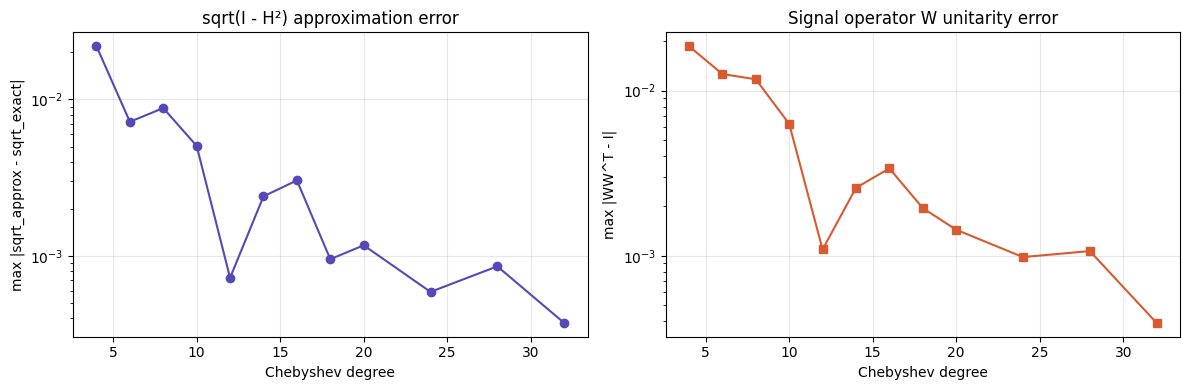


Degree vs error:
  d= 4: sqrt_err=2.19e-02, unitarity_err=1.86e-02
  d= 6: sqrt_err=7.19e-03, unitarity_err=1.26e-02
  d= 8: sqrt_err=8.80e-03, unitarity_err=1.17e-02
  d=10: sqrt_err=5.04e-03, unitarity_err=6.29e-03
  d=12: sqrt_err=7.25e-04, unitarity_err=1.09e-03
  d=14: sqrt_err=2.40e-03, unitarity_err=2.58e-03
  d=16: sqrt_err=3.04e-03, unitarity_err=3.38e-03
  d=18: sqrt_err=9.54e-04, unitarity_err=1.94e-03
  d=20: sqrt_err=1.17e-03, unitarity_err=1.44e-03
  d=24: sqrt_err=5.90e-04, unitarity_err=9.81e-04
  d=28: sqrt_err=8.59e-04, unitarity_err=1.07e-03
  d=32: sqrt_err=3.74e-04, unitarity_err=3.92e-04


In [ ]:
degrees = [4, 6, 8, 10, 12, 14, 16, 18, 20, 24, 28, 32]
errors = []
unitarity_errors = []

for d in degrees:
    try:
        _, _, info_d = build_signal_operator(H, degree=d)
        errors.append(info_d["sqrt_error"])
        unitarity_errors.append(info_d["W_unitarity_error"])
    except Exception as e:
        print(f"degree {d} failed: {e}")
        errors.append(np.nan)
        unitarity_errors.append(np.nan)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))

ax1.semilogy(degrees, errors, "o-", color="#534AB7")
ax1.set_xlabel("Chebyshev degree")
ax1.set_ylabel("max |sqrt_approx - sqrt_exact|")
ax1.set_title("sqrt(I - H²) approximation error")
ax1.grid(True, alpha=0.3)

ax2.semilogy(degrees, unitarity_errors, "s-", color="#D85A30")
ax2.set_xlabel("Chebyshev degree")
ax2.set_ylabel("max |WW^T - I|")
ax2.set_title("Signal operator W unitarity error")
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()
print("\nDegree vs error:")
for d, e, u in zip(degrees, errors, unitarity_errors):
    print(f"  d={d:2d}: sqrt_err={e:.2e}, unitarity_err={u:.2e}")

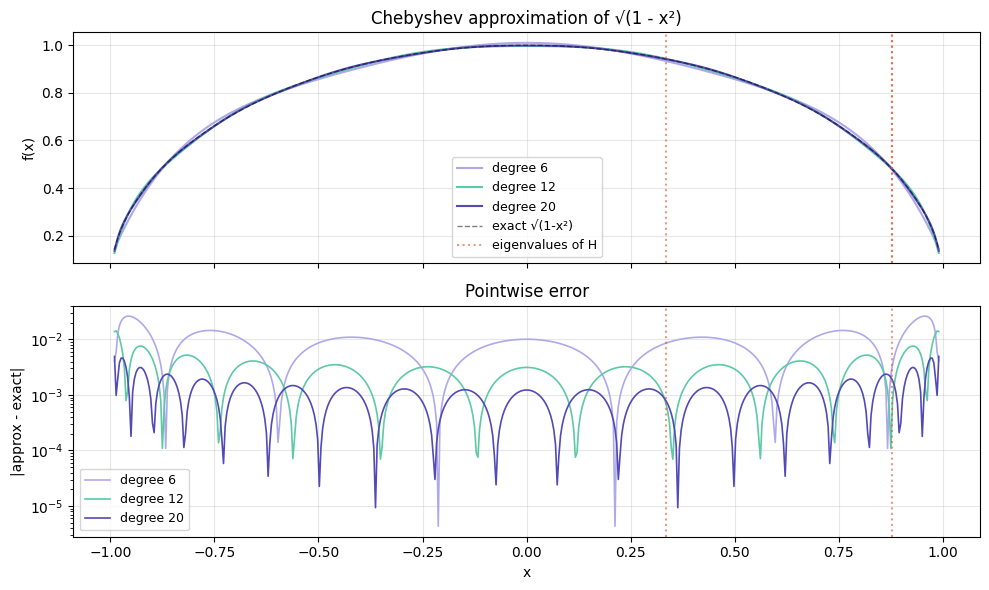

In [ ]:
x = np.linspace(-0.99, 0.99, 500)
exact = np.sqrt(1 - x**2)

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(10, 6), sharex=True)

for d, color in [(6, "#AFA9EC"), (12, "#5DCAA5"), (20, "#534AB7")]:
    coefs, sc = chebyshev_approx(degree=d)
    poly_fn = np.polynomial.polynomial.Polynomial(coefs)
    approx = poly_fn(x) / sc

    ax1.plot(x, approx, label=f"degree {d}", color=color, linewidth=1.5)
    ax2.semilogy(x, np.abs(approx - exact) + 1e-16, color=color, label=f"degree {d}", linewidth=1.2)

ax1.plot(x, exact, "k--", alpha=0.5, label="exact √(1-x²)", linewidth=1)

# Mark eigenvalues of H
for l in np.linalg.eigvalsh(H):
    ax1.axvline(l, color="#D85A30", linestyle=":", alpha=0.6)
    ax2.axvline(l, color="#D85A30", linestyle=":", alpha=0.6)

ax1.axvline(l, color="#D85A30", linestyle=":", alpha=0.6, label="eigenvalues of H")

ax1.set_ylabel("f(x)")
ax1.set_title("Chebyshev approximation of √(1 - x²)")
ax1.legend(fontsize=9)
ax1.grid(True, alpha=0.3)

ax2.set_xlabel("x")
ax2.set_ylabel("|approx - exact|")
ax2.set_title("Pointwise error")
ax2.legend(fontsize=9)
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()